In [81]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

In [82]:
oplogs = pd.read_excel('project.xlsx')
oplogs

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,param_2,extra_1,extra_2,level
0,android,1000001,a1000001ES1,2023-02-01 08:00:02,ES,1.01,app_install_start,0.0,NaN,organic,NaN,0
1,android,1000001,a1000001ES1,2023-02-01 08:00:02,ES,1.01,performance,27.0,NaN,samsung,galaxy a52,0
2,android,1000001,a1000001ES1,2023-02-01 08:01:16,ES,1.01,app_install_finish,74.0,NaN,NaN,NaN,0
3,android,1000001,a1000001ES1,2023-02-01 08:01:42,ES,1.01,loading_finish,26.0,NaN,NaN,NaN,0
4,android,1000001,a1000001ES1,2023-02-01 08:01:42,ES,1.01,tutorial_step_start,1.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
30984,iOS,1002499,i1002499GE1,2023-02-15 17:34:55,GE,1.02,tutorial_step_start,5.0,NaN,NaN,NaN,0
30985,iOS,1002499,i1002499GE1,2023-02-15 17:35:07,GE,1.02,tutorial_step_finish,5.0,NaN,NaN,NaN,0
30986,iOS,1002499,i1002499GE1,2023-02-15 17:35:07,GE,1.02,tutorial_step_start,6.0,NaN,NaN,NaN,0
30987,iOS,1002499,i1002499GE1,2023-02-15 17:35:11,GE,1.02,tutorial_step_finish,6.0,NaN,NaN,NaN,0


## **User Info**

In [83]:
# создаю таблицу и объединяю ее с найденными данными
user_info = oplogs[['user_id', 'country', 'platform_type', 'event_name', 'extra_1', 'param_1', 'user_time', 'version']]\
.merge(oplogs.groupby('user_id').agg(last_time=('user_time', 'max')).reset_index(), on='user_id')\
.merge(oplogs.loc[oplogs.groupby('user_id')['user_time'].idxmax()][['user_id', 'version']]\
       .rename(columns={'version': 'last_version'})\
       .reset_index(drop=True), on='user_id')\
.merge(oplogs.groupby('user_id').agg(max_level=('level', 'max')).reset_index(), on='user_id')\
.merge(oplogs.groupby('user_id').agg(amount_gold=('param_2', lambda x: x[oplogs.loc[x.index, 'event_name'] == 'res_movement_inc']\
       .iloc[-1] if any(oplogs.loc[x.index, 'event_name'] == 'res_movement_inc') else 0))\
       .reset_index())\
.merge(oplogs.query("event_name == 'res_movement_inc' and extra_1 == 'bronze_cup'")\
       .sort_values('user_time').groupby('user_id').tail(1)[['user_id', 'param_2']]\
       .rename(columns={'param_2': 'amount_bronze_cup'}), on='user_id', how='left')\
.merge(oplogs.query("event_name == 'res_movement_inc' and extra_1 == 'silver_cup'")\
       .sort_values('user_time').groupby('user_id').tail(1)[['user_id', 'param_2']]\
       .rename(columns={'param_2': 'amount_silver_cup'}), on='user_id', how='left')\
.merge(oplogs.query("event_name == 'res_movement_inc' and extra_1 == 'gold_cup'")\
       .sort_values('user_time').groupby('user_id').tail(1)[['user_id', 'param_2']]\
       .rename(columns={'param_2': 'amount_gold_cup'}), on='user_id', how='left')\
.fillna({'amount_bronze_cup': 0, 'amount_silver_cup': 0, 'amount_gold_cup': 0})\
.merge(oplogs.groupby('user_id').agg(total_revenue=('param_2', lambda x: x[oplogs['event_name'] == 'purchase'].sum())).reset_index(), on='user_id')\
.drop_duplicates(subset=['user_id'])\
.rename(columns={'version':'first_version', 'extra_1':'type_trafic', 'param_1':'CAC', 'user_time':'first_time'}, inplace=False)

user_info

,user_id,country,platform_type,event_name,type_trafic,CAC,first_time,first_version,last_time,last_version,max_level,amount_gold,amount_bronze_cup,amount_silver_cup,amount_gold_cup,total_revenue
0,1000001,ES,android,app_install_start,organic,0.0,2023-02-01 08:00:02,1.01,2023-02-01 08:02:05,1.01,0,0.0,0.0,0.0,0.0,0.0
13,1000004,RU,android,app_install_start,organic,0.0,2023-02-01 08:29:34,1.01,2023-02-01 08:30:42,1.01,0,0.0,0.0,0.0,0.0,0.0
18,1000006,CA,iOS,app_install_start,organic,0.0,2023-02-01 08:47:23,1.01,2023-02-01 08:50:14,1.01,2,650.0,0.0,0.0,0.0,0.0
46,1000007,GE,android,app_install_start,organic,0.0,2023-02-01 08:49:45,1.01,2023-02-01 08:51:12,1.01,0,0.0,0.0,0.0,0.0,0.0
54,1000008,RU,iOS,app_install_start,organic,0.0,2023-02-01 09:03:20,1.01,2023-02-02 08:45:35,1.01,10,3050.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30878,1002492,PL,android,app_install_start,paid,0.2,2023-02-15 16:40:28,1.02,2023-02-15 16:41:45,1.02,0,0.0,0.0,0.0,0.0,0.0
30883,1002495,GE,android,app_install_start,organic,0.0,2023-02-15 17:13:19,1.02,2023-02-15 17:14:28,1.02,0,0.0,0.0,0.0,0.0,0.0
30890,1002497,BY,android,app_install_start,organic,0.0,2023-02-15 17:26:46,1.02,2023-02-15 17:30:33,1.02,2,650.0,0.0,0.0,0.0,0.0
30918,1002498,RU,android,app_install_start,organic,0.0,2023-02-15 17:31:00,1.02,2023-02-15 18:39:24,1.02,6,1150.0,1.0,0.0,0.0,0.0


In [84]:
# вывожу массив users, которые делали покупки (с помощью функции unique, чтобы отсортировать платящих)
payer_users = oplogs[oplogs['event_name'] == 'purchase']['user_id'].unique()
payer_users

array([1000028, 1000079, 1000208, 1000358, 1000399, 1000444, 1000449,
       1000521, 1000629, 1000660, 1000677, 1000694, 1000710, 1000716,
       1000765, 1000874, 1001015, 1001116, 1001191, 1001209, 1001247,
       1001434, 1001506, 1001558, 1001661, 1001665, 1001712, 1001804,
       1001818, 1001859, 1001955, 1002122, 1002315, 1002398, 1002402,
       1002461])

In [85]:
# добавляю столбец 'payer' с помощью анонимной функции lambda
user_info[['payer']] = oplogs.apply(lambda x: pd.Series({'payer': 1 if x['user_id'] in payer_users else 0}), axis=1)

Вычисление массива дат, когда игрок был активен

In [86]:
# извлекаю временные хар-ки с помощью dt (перевод в формат даты)
user_date = oplogs['user_time'].dt.date\
        .groupby(oplogs['user_id'])\
        .apply(lambda x: sorted(x.unique())).reset_index()\
        .rename(columns={'user_time': 'dates'})
user_date

,user_id,dates
0,1000001,[2023-02-01]
1,1000004,[2023-02-01]
2,1000006,[2023-02-01]
3,1000007,[2023-02-01]
4,1000008,"[2023-02-01, 2023-02-02]"
...,...,...
1377,1002492,[2023-02-15]
1378,1002495,[2023-02-15]
1379,1002497,[2023-02-15]
1380,1002498,[2023-02-15]


In [87]:
user_date['dates'] = user_date['dates'].apply(lambda x: ', '.join([date.strftime("%Y-%m-%d") for date in x]))
user_date

,user_id,dates
0,1000001,2023-02-01
1,1000004,2023-02-01
2,1000006,2023-02-01
3,1000007,2023-02-01
4,1000008,"2023-02-01, 2023-02-02"
...,...,...
1377,1002492,2023-02-15
1378,1002495,2023-02-15
1379,1002497,2023-02-15
1380,1002498,2023-02-15


In [88]:
# присоединяю массив с датами
user_info = user_info.merge(user_date, on='user_id')
user_info

,user_id,country,platform_type,event_name,type_trafic,CAC,first_time,first_version,last_time,last_version,max_level,amount_gold,amount_bronze_cup,amount_silver_cup,amount_gold_cup,total_revenue,payer,dates
0,1000001,ES,android,app_install_start,organic,0.0,2023-02-01 08:00:02,1.01,2023-02-01 08:02:05,1.01,0,0.0,0.0,0.0,0.0,0.0,0,2023-02-01
1,1000004,RU,android,app_install_start,organic,0.0,2023-02-01 08:29:34,1.01,2023-02-01 08:30:42,1.01,0,0.0,0.0,0.0,0.0,0.0,0,2023-02-01
2,1000006,CA,iOS,app_install_start,organic,0.0,2023-02-01 08:47:23,1.01,2023-02-01 08:50:14,1.01,2,650.0,0.0,0.0,0.0,0.0,0,2023-02-01
3,1000007,GE,android,app_install_start,organic,0.0,2023-02-01 08:49:45,1.01,2023-02-01 08:51:12,1.01,0,0.0,0.0,0.0,0.0,0.0,0,2023-02-01
4,1000008,RU,iOS,app_install_start,organic,0.0,2023-02-01 09:03:20,1.01,2023-02-02 08:45:35,1.01,10,3050.0,1.0,0.0,0.0,0.0,0,"2023-02-01, 2023-02-02"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,1002492,PL,android,app_install_start,paid,0.2,2023-02-15 16:40:28,1.02,2023-02-15 16:41:45,1.02,0,0.0,0.0,0.0,0.0,0.0,0,2023-02-15
1378,1002495,GE,android,app_install_start,organic,0.0,2023-02-15 17:13:19,1.02,2023-02-15 17:14:28,1.02,0,0.0,0.0,0.0,0.0,0.0,0,2023-02-15
1379,1002497,BY,android,app_install_start,organic,0.0,2023-02-15 17:26:46,1.02,2023-02-15 17:30:33,1.02,2,650.0,0.0,0.0,0.0,0.0,0,2023-02-15
1380,1002498,RU,android,app_install_start,organic,0.0,2023-02-15 17:31:00,1.02,2023-02-15 18:39:24,1.02,6,1150.0,1.0,0.0,0.0,0.0,0,2023-02-15


## **User Session**

In [89]:
# создаю таблицу, удаляю дубликаты
user_session = oplogs[['user_id', 'platform_type', 'version', 'session_id']]\
.drop_duplicates(subset=['user_id', 'session_id'])
user_session

,user_id,platform_type,version,session_id
0,1000001,android,1.01,a1000001ES1
13,1000004,android,1.01,a1000004RU1
18,1000006,iOS,1.01,i1000006CA1
46,1000007,android,1.01,a1000007GE1
54,1000008,iOS,1.01,i1000008RU1
...,...,...,...,...
30883,1002495,android,1.02,a1002495GE1
30890,1002497,android,1.02,a1002497BY1
30918,1002498,android,1.02,a1002498RU1
30965,1002498,android,1.02,a1002498RU2


In [90]:
# добавляю session_number - порядковый номер сессии, группируя по user_id
user_session['session_number'] = user_session.groupby('user_id').cumcount() + 1
user_session

,user_id,platform_type,version,session_id,session_number
0,1000001,android,1.01,a1000001ES1,1
13,1000004,android,1.01,a1000004RU1,1
18,1000006,iOS,1.01,i1000006CA1,1
46,1000007,android,1.01,a1000007GE1,1
54,1000008,iOS,1.01,i1000008RU1,1
...,...,...,...,...,...
30883,1002495,android,1.02,a1002495GE1,1
30890,1002497,android,1.02,a1002497BY1,1
30918,1002498,android,1.02,a1002498RU1,1
30965,1002498,android,1.02,a1002498RU2,2


In [91]:
# нахожу время старта сессий
time_start_session = oplogs.query("event_name == 'loading_finish' ")\
        .groupby(['user_id', 'session_id'])\
        .agg(time_start_session=('user_time', 'min'))\
        .reset_index()
time_start_session

,user_id,session_id,time_start_session
0,1000001,a1000001ES1,2023-02-01 08:01:42
1,1000004,a1000004RU1,2023-02-01 08:30:42
2,1000006,i1000006CA1,2023-02-01 08:48:30
3,1000007,a1000007GE1,2023-02-01 08:51:00
4,1000008,i1000008RU1,2023-02-01 09:04:44
...,...,...,...
1518,1002495,a1002495GE1,2023-02-15 17:14:24
1519,1002497,a1002497BY1,2023-02-15 17:28:41
1520,1002498,a1002498RU1,2023-02-15 17:32:19
1521,1002498,a1002498RU2,2023-02-15 18:37:46


In [92]:
# присоединяю через how=left, т.к. в правой табл. только 1523, а в левой 1566
user_session = user_session.merge(time_start_session, on=['user_id', 'session_id'], how='left')
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44
...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46


In [93]:
# нахожу время окончаний сессий
time_finish_session = oplogs.groupby(['user_id', 'session_id']).agg(time_finish_session=('user_time', 'max')).reset_index()
time_finish_session

,user_id,session_id,time_finish_session
0,1000001,a1000001ES1,2023-02-01 08:02:05
1,1000004,a1000004RU1,2023-02-01 08:30:42
2,1000006,i1000006CA1,2023-02-01 08:50:14
3,1000007,a1000007GE1,2023-02-01 08:51:12
4,1000008,i1000008RU1,2023-02-01 09:11:19
...,...,...,...
1561,1002495,a1002495GE1,2023-02-15 17:14:28
1562,1002497,a1002497BY1,2023-02-15 17:30:33
1563,1002498,a1002498RU1,2023-02-15 17:38:00
1564,1002498,a1002498RU2,2023-02-15 18:39:24


In [94]:
# присоединяю (по умолчанию inner – соединяет совпадающие строки)
user_session = user_session.merge(time_finish_session, on=['user_id', 'session_id'])
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19
...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24


In [95]:
# считаю длину каждой сессии и конвертирую в формат секунд
user_session['length_session'] = (user_session['time_finish_session'] - user_session['time_start_session']).dt.total_seconds()
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0
...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0


In [96]:
# считаю кол-во полученных уровней игроком в одной сессии
amount_get_level = oplogs.groupby(['user_id', 'session_id']).agg(amount_get_level=('level', 'max')).reset_index()
amount_get_level

,user_id,session_id,amount_get_level
0,1000001,a1000001ES1,0
1,1000004,a1000004RU1,0
2,1000006,i1000006CA1,2
3,1000007,a1000007GE1,0
4,1000008,i1000008RU1,6
...,...,...,...
1561,1002495,a1002495GE1,0
1562,1002497,a1002497BY1,2
1563,1002498,a1002498RU1,5
1564,1002498,a1002498RU2,6


In [97]:
# присоединяю таблицу
user_session = user_session.merge(amount_get_level, on=['user_id', 'session_id']).fillna(0)
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session,amount_get_level
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0,0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0,0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0,2
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0,0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0,6
...,...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0,0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0,2
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0,5
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0,6


In [98]:
# проверяю какие ресурсы есть у игроков, чтобы достать название голды
unique = oplogs[oplogs['event_name'] == 'res_movement_inc']['extra_1'].unique()
unique

array(['gold', 'token', 'bronze_cup', 'silver_cup', 'dynamite', 'bomb',
       'hammer'], dtype=object)

In [99]:
# считаю кол-во полученной голды игроком в одной сессии
amount_get_gold = oplogs.query("event_name == 'res_movement_outc' or event_name == 'res_movement_inc'")\
.query("extra_1 == 'gold'")\
.groupby(['user_id', 'session_id']).agg(amount_get_gold=('param_2', 'last')).reset_index()

amount_get_gold

,user_id,session_id,amount_get_gold
0,1000006,i1000006CA1,650.0
1,1000008,i1000008RU1,1050.0
2,1000008,i1000008RU2,3050.0
3,1000014,a1000014KZ1,650.0
4,1000022,a1000022US1,1050.0
...,...,...,...
677,1002474,a1002474RU1,850.0
678,1002486,a1002486US1,650.0
679,1002497,a1002497BY1,650.0
680,1002498,a1002498RU1,1050.0


In [100]:
# присоединяю таблицу через how=left, также заполняю NaN=0
user_session = user_session.merge(amount_get_gold, on=['user_id', 'session_id'], how='left').fillna(0)
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session,amount_get_level,amount_get_gold
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0,0,0.0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0,0,0.0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0,2,650.0
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0,0,0.0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0,6,1050.0
...,...,...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0,0,0.0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0,2,650.0
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0,5,1050.0
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0,6,1150.0


In [101]:
# считаю кол-во полученных бронзовых кубков игроком в одной сессии
amount_get_bronze_cup = (oplogs.query('extra_1 == "bronze_cup"').groupby(['user_id', 'session_id']).size().reset_index(name='amount_get_bronze_cup'))
amount_get_bronze_cup

,user_id,session_id,amount_get_bronze_cup
0,1000008,i1000008RU1,1
1,1000022,a1000022US1,1
2,1000028,a1000028ES1,1
3,1000061,a1000061RU1,1
4,1000076,i1000076RU1,1
...,...,...,...
135,1002402,a1002402NL1,1
136,1002426,a1002426RU1,1
137,1002428,a1002428IT1,1
138,1002456,i1002456RU1,1


In [102]:
# присоединяю таблицу через how=left, также заполняю NaN=0
user_session = user_session.merge(amount_get_bronze_cup, on=['user_id', 'session_id'], how='left').fillna(0)
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session,amount_get_level,amount_get_gold,amount_get_bronze_cup
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0,0,0.0,0.0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0,0,0.0,0.0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0,2,650.0,0.0
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0,0,0.0,0.0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0,6,1050.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0,0,0.0,0.0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0,2,650.0,0.0
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0,5,1050.0,0.0
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0,6,1150.0,1.0


In [103]:
# считаю кол-во полученных серебрянных кубков игроком в одной сессии
amount_get_silver_cup = (oplogs.query('extra_1 == "silver_cup"').groupby(['user_id', 'session_id']).size().reset_index(name='amount_get_silver_cup'))
amount_get_silver_cup

,user_id,session_id,amount_get_silver_cup
0,1000022,a1000022US2,1
1,1000076,i1000076RU2,1
2,1000108,i1000108KZ2,1
3,1000158,a1000158DE2,1
4,1000262,a1000262US2,1
5,1000263,a1000263US2,1
6,1000390,a1000390RU2,1
7,1000402,a1000402PL2,1
8,1000414,a1000414PL2,1
9,1000460,a1000460KZ2,1


In [104]:
# присоединяю таблицу через how=left, также заполняю NaN=0
user_session = user_session.merge(amount_get_silver_cup, on=['user_id', 'session_id'], how='left').fillna(0)
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session,amount_get_level,amount_get_gold,amount_get_bronze_cup,amount_get_silver_cup
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0,0,0.0,0.0,0.0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0,0,0.0,0.0,0.0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0,2,650.0,0.0,0.0
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0,0,0.0,0.0,0.0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0,6,1050.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0,0,0.0,0.0,0.0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0,2,650.0,0.0,0.0
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0,5,1050.0,0.0,0.0
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0,6,1150.0,1.0,0.0


In [105]:
# считаю кол-во полученных серебрянных кубков игроком в одной сессии
amount_get_gold_cup = (oplogs.query('extra_1 == "gold_cup"').groupby(['user_id', 'session_id']).size().reset_index(name='amount_get_gold_cup'))
amount_get_gold_cup

,user_id,session_id,amount_get_gold_cup


In [106]:
#присоединяю таблицу через how=left, также заполняю NaN=0
user_session = user_session.merge(amount_get_gold_cup, on=['user_id', 'session_id'], how='left').fillna(0)
user_session

,user_id,platform_type,version,session_id,session_number,time_start_session,time_finish_session,length_session,amount_get_level,amount_get_gold,amount_get_bronze_cup,amount_get_silver_cup,amount_get_gold_cup
0,1000001,android,1.01,a1000001ES1,1,2023-02-01 08:01:42,2023-02-01 08:02:05,23.0,0,0.0,0.0,0.0,0.0
1,1000004,android,1.01,a1000004RU1,1,2023-02-01 08:30:42,2023-02-01 08:30:42,0.0,0,0.0,0.0,0.0,0.0
2,1000006,iOS,1.01,i1000006CA1,1,2023-02-01 08:48:30,2023-02-01 08:50:14,104.0,2,650.0,0.0,0.0,0.0
3,1000007,android,1.01,a1000007GE1,1,2023-02-01 08:51:00,2023-02-01 08:51:12,12.0,0,0.0,0.0,0.0,0.0
4,1000008,iOS,1.01,i1000008RU1,1,2023-02-01 09:04:44,2023-02-01 09:11:19,395.0,6,1050.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,1002495,android,1.02,a1002495GE1,1,2023-02-15 17:14:24,2023-02-15 17:14:28,4.0,0,0.0,0.0,0.0,0.0
1562,1002497,android,1.02,a1002497BY1,1,2023-02-15 17:28:41,2023-02-15 17:30:33,112.0,2,650.0,0.0,0.0,0.0
1563,1002498,android,1.02,a1002498RU1,1,2023-02-15 17:32:19,2023-02-15 17:38:00,341.0,5,1050.0,0.0,0.0,0.0
1564,1002498,android,1.02,a1002498RU2,2,2023-02-15 18:37:46,2023-02-15 18:39:24,98.0,6,1150.0,1.0,0.0,0.0


## **User Payments**

In [107]:
# создаю таблюцу user_payments
user_payments = oplogs[['user_id', 'platform_type', 'session_id', 'version', 'event_name', 'user_time', 'extra_1', 'extra_2', 'param_2', 'level']]\
.query("event_name == 'purchase'").sort_values(by='user_time', ascending=True)\
.rename(columns = {
    'user_time':'purchase_time',
    'extra_1':'item',
    'extra_2':'offer_id',
    'param_2':'price'}, inplace=False)\
.reset_index(drop=True, inplace=False)\
.drop(columns = ['event_name'],axis = 1)
user_payments

,user_id,platform_type,session_id,version,purchase_time,item,offer_id,price,level
0,1000028,android,a1000028ES2,1.01,2023-02-02 11:31:44,shop,13,0.99,9
1,1000208,iOS,i1000208RU1,1.01,2023-02-02 12:33:32,shop,42,3.99,3
2,1000079,android,a1000079PL2,1.01,2023-02-02 18:43:35,offer,61,2.99,8
3,1000399,android,a1000399RU2,1.01,2023-02-03 14:40:51,shop,23,1.99,5
4,1000521,android,a1000521RU1,1.01,2023-02-04 07:25:41,shop,42,3.99,3
5,1000358,iOS,i1000358US2,1.01,2023-02-04 08:09:12,offer,61,2.99,8
6,1000444,iOS,i1000444RU2,1.01,2023-02-04 19:32:33,offer,61,2.99,8
7,1000449,iOS,i1000449KZ2,1.01,2023-02-04 20:20:19,shop,13,0.99,9
8,1000660,android,a1000660GE2,1.01,2023-02-05 03:08:13,shop,23,1.99,5
9,1000677,android,a1000677RU1,1.01,2023-02-05 04:35:05,shop,42,3.99,2


In [108]:
# добавление столбца с порядковым номером покупки с помощью range
a = len(user_payments['session_id'])
user_payments['purchase_number'] = range(1, a+1)
user_payments

,user_id,platform_type,session_id,version,purchase_time,item,offer_id,price,level,purchase_number
0,1000028,android,a1000028ES2,1.01,2023-02-02 11:31:44,shop,13,0.99,9,1
1,1000208,iOS,i1000208RU1,1.01,2023-02-02 12:33:32,shop,42,3.99,3,2
2,1000079,android,a1000079PL2,1.01,2023-02-02 18:43:35,offer,61,2.99,8,3
3,1000399,android,a1000399RU2,1.01,2023-02-03 14:40:51,shop,23,1.99,5,4
4,1000521,android,a1000521RU1,1.01,2023-02-04 07:25:41,shop,42,3.99,3,5
5,1000358,iOS,i1000358US2,1.01,2023-02-04 08:09:12,offer,61,2.99,8,6
6,1000444,iOS,i1000444RU2,1.01,2023-02-04 19:32:33,offer,61,2.99,8,7
7,1000449,iOS,i1000449KZ2,1.01,2023-02-04 20:20:19,shop,13,0.99,9,8
8,1000660,android,a1000660GE2,1.01,2023-02-05 03:08:13,shop,23,1.99,5,9
9,1000677,android,a1000677RU1,1.01,2023-02-05 04:35:05,shop,42,3.99,2,10


In [109]:
# сохранение созданных таблиц
user_info.to_excel('user_info.xlsx', index=False)
user_session.to_excel('user_session.xlsx', index=False)
user_payments.to_excel('user_payments.xlsx', index=False)


## **ARPU (Average Revenue Per User)**

*ARPU = Revenue / Active Users*

In [110]:
import plotly.express as px
import plotly.graph_objects as go

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
total_revenue = round(user_info['total_revenue'].sum(), 2)
total_users = user_info['user_id'].nunique()
print('Общий доход:', total_revenue)
print('Общее количество пользователей:', total_users)

Общий доход: 105.64
Общее количество пользователей: 1382


In [113]:
# вычисление ARPU (Average Revenue Per User)
ARPU = round(total_revenue / total_users, 2)
ARPU

0.08

In [114]:
# вычисление ARPU по странам
ARPU_country = user_info.groupby('country').agg(
    total_revenue=('total_revenue', 'sum'),
    total_users=('user_id', 'nunique')
).reset_index()
ARPU_country['ARPU'] = round(ARPU_country['total_revenue'] / ARPU_country['total_users'], 2)
ARPU_country.sort_values(by='ARPU', ascending=False)

,country,total_revenue,total_users,ARPU
12,US,26.92,204,0.13
3,ES,7.97,71,0.11
5,IT,7.98,72,0.11
0,BY,6.98,74,0.09
7,LT,0.99,13,0.08
10,PL,8.97,106,0.08
11,RU,32.90,390,0.08
1,CA,1.99,56,0.04
2,DE,4.98,115,0.04
4,GE,1.99,76,0.03


<ipython-input-115-b3bd833b06b7>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




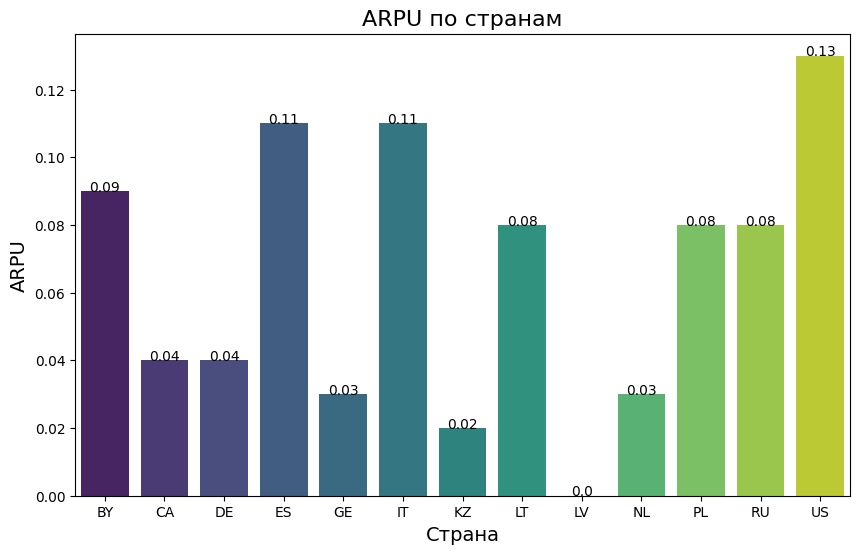

In [115]:
# построение столбчатой диаграммы ARPU по странам
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='ARPU', data=ARPU_country, palette='viridis')

# добавление подписей и заголовков
plt.title('ARPU по странам', fontsize=16)
plt.xlabel('Страна', fontsize=14)
plt.ylabel('ARPU', fontsize=14)

for index, row in ARPU_country.iterrows():
    plt.text(row.name, row.ARPU, round(row.ARPU, 2), color='black', ha="center")

plt.show()

In [116]:
# вычисление ARPU по платформе
ARPU_platform = user_info.groupby('platform_type').agg(
    total_revenue=('total_revenue', 'sum'),
    total_users=('user_id', 'nunique')
).reset_index()
ARPU_platform['ARPU'] = round(ARPU_platform['total_revenue'] / ARPU_platform['total_users'], 2)
ARPU_platform.sort_values(by='ARPU', ascending=False)

,platform_type,total_revenue,total_users,ARPU
1,iOS,48.85,540,0.09
0,android,56.79,842,0.07


<ipython-input-117-c5b0f84dbd38>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




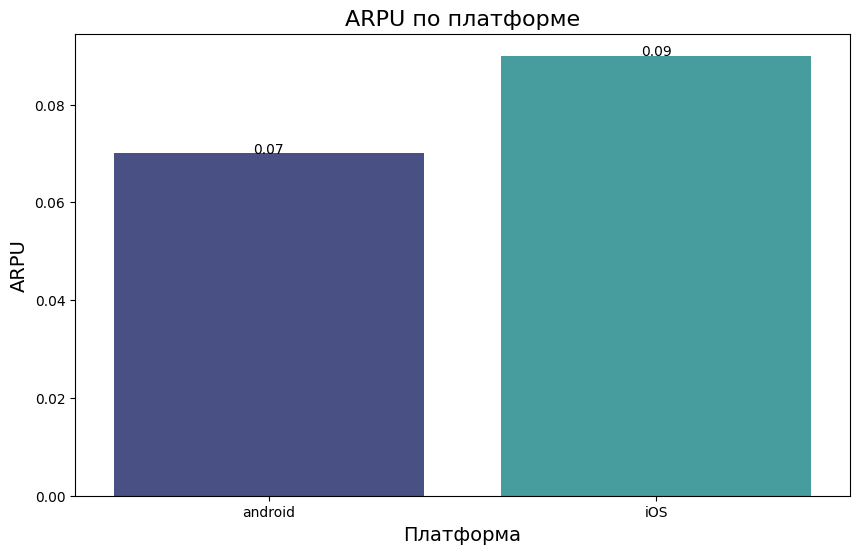

In [117]:
# построение столбчатой диаграммы ARPU по платформе
plt.figure(figsize=(10, 6))
sns.barplot(x='platform_type', y='ARPU', data=ARPU_platform, palette='mako')

# добавление подписей и заголовков
plt.title('ARPU по платформе', fontsize=16)
plt.xlabel('Платформа', fontsize=14)
plt.ylabel('ARPU', fontsize=14)

for index, row in ARPU_platform.iterrows():
    plt.text(row.name, row.ARPU, round(row.ARPU, 2), color='black', ha="center")

plt.show()

In [118]:
# вычисление ARPU по типу трафика
ARPU_trafic = user_info.groupby('type_trafic').agg(
    total_revenue=('total_revenue', 'sum'),
    total_users=('user_id', 'nunique')
).reset_index()
ARPU_trafic['ARPU'] = round(ARPU_trafic['total_revenue'] / ARPU_trafic['total_users'], 2)
ARPU_trafic.sort_values(by='ARPU', ascending=False)

,type_trafic,total_revenue,total_users,ARPU
0,organic,86.69,1095,0.08
1,paid,18.95,287,0.07


<ipython-input-119-9e9d4e3c2a46>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




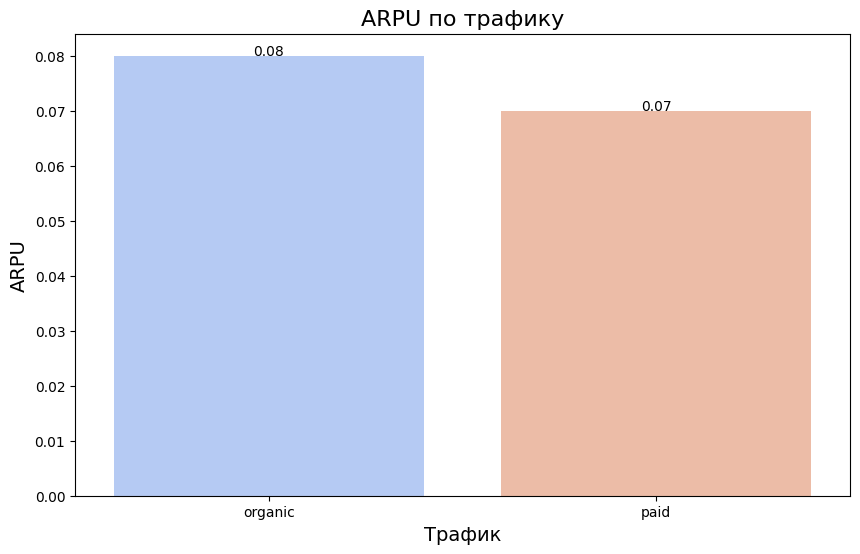

In [119]:
# построение столбчатой диаграммы ARPU по платформе
plt.figure(figsize=(10, 6))
sns.barplot(x='type_trafic', y='ARPU', data=ARPU_trafic, palette='coolwarm')

# добавление подписей и заголовков
plt.title('ARPU по трафику', fontsize=16)
plt.xlabel('Трафик', fontsize=14)
plt.ylabel('ARPU', fontsize=14)

for index, row in ARPU_trafic.iterrows():
    plt.text(row.name, row.ARPU, round(row.ARPU, 2), color='black', ha="center")

plt.show()

## **ARPPU (Average Revenue Per Paying User)**

*ARPPU = Revenue / Paying Users*

In [120]:
# вычисление ARPPU в разрезе стран
ARPPU_country = user_info[user_info['payer'] == 1].groupby('country').agg(
    total_revenue=('total_revenue', 'sum'),
    total_paying_users=('user_id', 'nunique')
).reset_index()
ARPPU_country['ARPPU'] = round(ARPPU_country['total_revenue'] / ARPPU_country['total_paying_users'], 2)
ARPPU_country = ARPPU_country.sort_values(by='ARPPU', ascending=False)
ARPPU_country

,country,total_revenue,total_paying_users,ARPPU
5,IT,7.98,2,3.99
0,BY,6.98,2,3.49
11,US,26.92,8,3.36
10,RU,32.90,10,3.29
9,PL,8.97,3,2.99
3,ES,7.97,3,2.66
2,DE,4.98,2,2.49
1,CA,1.99,1,1.99
4,GE,1.99,1,1.99
6,KZ,2.98,2,1.49


In [121]:
# вычисление ARPPU в разрезе платформы
ARPPU_platform_type = user_info[user_info['payer'] == 1].groupby('platform_type').agg(
    total_revenue=('total_revenue', 'sum'),
    total_paying_users=('user_id', 'nunique')
).reset_index()
ARPPU_platform_type['ARPPU'] = round(ARPPU_platform_type['total_revenue'] / ARPPU_platform_type['total_paying_users'], 2)
ARPPU_platform_type = ARPPU_platform_type.sort_values(by='ARPPU', ascending=False)
ARPPU_platform_type

,platform_type,total_revenue,total_paying_users,ARPPU
1,iOS,48.85,15,3.26
0,android,56.79,21,2.70


In [122]:
# вычисление ARPPU по типу трафика
ARPPU_type_trafic = user_info[user_info['payer'] == 1].groupby('type_trafic').agg(
    total_revenue=('total_revenue', 'sum'),
    total_paying_users=('user_id', 'nunique')
).reset_index()
ARPPU_type_trafic['ARPPU'] = round(ARPPU_type_trafic['total_revenue'] / ARPPU_type_trafic['total_paying_users'], 2)
ARPPU_type_trafic = ARPPU_type_trafic.sort_values(by='ARPPU', ascending=False)
ARPPU_type_trafic

,type_trafic,total_revenue,total_paying_users,ARPPU
1,paid,18.95,5,3.79
0,organic,86.69,31,2.80


## **Paying Conversion**

*Paying Conversion = Paying Users / New Users * 100%*

Вычисление процента пользователей, которые совершили покупку, из тех, кто установил игру

In [123]:
# определение платящих пользователей
paying_users = user_info[user_info['payer'] == 1]['user_id'].nunique()
paying_users

36

In [124]:
# вычисление конверсии в платеж
conversion_rate = round((paying_users / total_users * 100), 2)
print(f'Конверсия в платеж: {conversion_rate}%')

Конверсия в платеж: 2.6%


In [125]:
# создание датафрейма платящих и неплатящих пользователей для визуализации
conversion_data = pd.DataFrame({
    'Category': ['Платящие пользователи', 'Неплатящие пользователи'],
    'Count': [paying_users, total_users - paying_users]
})

In [126]:
# построение круговой диаграммы для визуализации доли платящих пользователей
fig = px.pie(conversion_data, values='Count', names='Category', title='Соотношение платящих и неплатящих пользователей')
fig.show()

## **LTV (Lifetime Value)**

*LTV = Revenue / Active Users*

Расчет среднего количества денег от одного игрока за всю его «жизнь» в игре.

Одним из наиболее частых способов применения этой метрики является **оценка покупаемого трафика**. Зная, сколько чистой прибыли приносят клиенты, можно также вычислить сколько денег можно потратить на их привлечение: CAC < LTV

In [127]:
ltv = round(total_revenue / total_users, 2)
cac_sum = user_info['CAC'].sum()
paid_traffic_users = user_info[user_info['type_trafic'] == 'paid']['user_id'].nunique()

print(f'LTV: {ltv}')
print(f'Расходы на привлечение клиентов: {cac_sum}')
print(f'Пользователи с платного трафика: {paid_traffic_users}')

LTV: 0.08
Расходы на привлечение клиентов: 97.0
Пользователи с платного трафика: 287


In [128]:
# нахожу стоимость привлечения одного клиента
cac = round(cac_sum / total_users, 2)
cac

0.07

In [129]:
cac < ltv

True

In [130]:
fig = go.Figure(data=[
    go.Bar(name='Lifetime Value', x=['LTV'], y=[ltv], marker_color='blue', text=f'{ltv}', textposition='auto'),
    go.Bar(name='Customer Acquisition Cost', x=['CAC'], y=[cac], marker_color='orange', text=f'{cac}', textposition='auto')])

fig.update_layout(
    title='Соотношение LTV и CAC',
    yaxis_title='Значение',
    xaxis_title='Метрика',
    barmode='group',
    showlegend=False)
fig.show()

Так как доля LTV заметно больше, чем CAC, это хороший знак, потому что чем больше процент LTV, тем выгоднее привлечение клиентов.

## **Построение воронки**

Воронка состоит из последовательности действий игроков и показывает, сколько уникальных пользователей совершили каждое из них: сколько человек сделали первый шаг, сколько затем перешли на второй и так далее

In [131]:
# создание датафрейма шагов пользователя
funnel_steps = [
    'app_install_start',   # Начало установки приложения
    'app_install_finish',  # Окончание установки приложения
    'tutorial_step_start', # Начало шага в туторе
    'tutorial_step_finish',# Окончание шага в туторе
    'lvl_up',              # Новый уровень игрока
    'purchase'             # Покупка ресурсов игроком
]

In [132]:
# фильтрация определенных строк из датафрейма
funnel_data = oplogs[oplogs['event_name'].isin(funnel_steps)]

In [133]:
# подсчёт количества уникальных пользователей на каждом шаге
funnel_users = funnel_data.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
funnel_users

,user_id
event_name,
app_install_start,1382
app_install_finish,1339
tutorial_step_start,1339
tutorial_step_finish,1163
lvl_up,498
purchase,36


In [134]:
# Построение воронки
fig = go.Figure(go.Funnel(
    y = funnel_users.index,
    x = funnel_users.values))

fig.update_layout(title="Воронка по шагам пользователя", width=800, height=600)
fig.show()

In [135]:
# создаю таблицу уровней
step_by_step = oplogs[['user_id', 'param_1', 'event_name']].query("event_name == 'lvl_up'").rename(columns={'param_1': 'lvl'})
step_by_step

,user_id,lvl,event_name
36,1000006,1.0,lvl_up
44,1000006,2.0,lvl_up
72,1000008,1.0,lvl_up
80,1000008,2.0,lvl_up
85,1000008,3.0,lvl_up
...,...,...,...
30944,1002498,2.0,lvl_up
30949,1002498,3.0,lvl_up
30954,1002498,4.0,lvl_up
30959,1002498,5.0,lvl_up


In [136]:
# подсчёт количества уникальных пользователей на каждом уровне
funnel_lvl = step_by_step.groupby('lvl')['user_id'].nunique().sort_index()
funnel_lvl

,user_id
lvl,
1.0,498
2.0,423
3.0,326
4.0,254
5.0,144
6.0,140
7.0,117
8.0,117
9.0,108


In [137]:
# Построение воронки
fig = go.Figure(go.Funnel(
    y = funnel_lvl.index,
    x = funnel_lvl.values,
    textinfo = "value+percent initial"))

fig.update_layout(title="Воронка по уровням пользователя", width=800, height=600)
fig.show()

## **А/В-тестирование**

In [138]:
import statsmodels.api as sm

Цель A/B тестирования: определить стоит ли понизить сложность прохождения 2 уровня в главе 1.

Ниже создаем две таблицы:
* для группы А оставляем уровень сложности
* для группы Б понижаем уровень сложности

In [139]:
# создание границ дат через переменную, в пределах которых проходил тест
start_date = pd.to_datetime('2023-02-03').date()
end_date = pd.to_datetime('2023-02-10').date()

In [140]:
# дублирование столбца user_time, обрезая время
oplogs['user_date'] = oplogs['user_time'].dt.date

In [141]:
# сокращение таблицы с учетом тестового периода
test_period_oplogs = oplogs[(oplogs['user_date'] >= start_date) & (oplogs['user_date'] <= end_date)]
test_period_oplogs

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,param_2,extra_1,extra_2,level,user_date
311,android,1000022,a1000022US3,2023-02-03 10:11:28,US,1.01,loading_finish,27.0,NaN,NaN,NaN,11,2023-02-03
312,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,chest_open,0.0,NaN,NaN,NaN,11,2023-02-03
313,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,res_movement_inc,500.0,3550.0,gold,chest,11,2023-02-03
314,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,res_movement_inc,10.0,15.0,token,chest,11,2023-02-03
315,android,1000022,a1000022US3,2023-02-03 10:12:04,US,1.01,res_movement_outc,3.0,12.0,token,stage_start,11,2023-02-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21338,android,1001679,a1001679KZ1,2023-02-10 23:34:57,KZ,1.02,res_movement_inc,100.0,950.0,gold,stage_win,5,2023-02-10
21339,android,1001679,a1001679KZ1,2023-02-10 23:35:09,KZ,1.02,res_movement_outc,1.0,5.0,token,stage_start,5,2023-02-10
21340,android,1001679,a1001679KZ1,2023-02-10 23:35:09,KZ,1.02,stage_start,5.0,1.0,bronze_loc,NaN,5,2023-02-10
21341,android,1001679,a1001679KZ1,2023-02-10 23:36:38,KZ,1.02,stage_lesion,5.0,1.0,bronze_loc,NaN,5,2023-02-10


In [142]:
# проверка типа данных user_id
print(test_period_oplogs['user_id'].dtype)

int64


In [143]:
# конвертирую user_id в string для применения регулярных выражений
test_period_oplogs['user_id'] = test_period_oplogs['user_id'].astype(str)
print(test_period_oplogs['user_id'].dtype)

object


<ipython-input-143-350a0b8efa11>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [144]:
# создаю тестовую группу А (user_id – заканчиваются на 0,1,2,3,4)
group_a = test_period_oplogs[test_period_oplogs['user_id'].str.endswith(('0', '1', '2', '3', '4'))]
group_a

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,param_2,extra_1,extra_2,level,user_date
311,android,1000022,a1000022US3,2023-02-03 10:11:28,US,1.01,loading_finish,27.0,NaN,NaN,NaN,11,2023-02-03
312,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,chest_open,0.0,NaN,NaN,NaN,11,2023-02-03
313,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,res_movement_inc,500.0,3550.0,gold,chest,11,2023-02-03
314,android,1000022,a1000022US3,2023-02-03 10:11:42,US,1.01,res_movement_inc,10.0,15.0,token,chest,11,2023-02-03
315,android,1000022,a1000022US3,2023-02-03 10:12:04,US,1.01,res_movement_outc,3.0,12.0,token,stage_start,11,2023-02-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21236,android,1001674,a1001674RU2,2023-02-10 23:41:18,RU,1.02,stage_start,5.0,1.0,bronze_loc,NaN,5,2023-02-10
21237,android,1001674,a1001674RU2,2023-02-10 23:42:17,RU,1.02,stage_win,5.0,1.0,bronze_loc,bronze_cup,5,2023-02-10
21238,android,1001674,a1001674RU2,2023-02-10 23:42:17,RU,1.02,lvl_up,6.0,NaN,NaN,NaN,6,2023-02-10
21239,android,1001674,a1001674RU2,2023-02-10 23:42:17,RU,1.02,res_movement_inc,1.0,1.0,bronze_cup,stage_win,6,2023-02-10


In [145]:
# создаю тестовую группу B: user_id – заканчиваются на 5,6,7,8,9
group_b = test_period_oplogs[test_period_oplogs['user_id'].str.endswith(('5', '6', '7', '8', '9'))]
group_b

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,param_2,extra_1,extra_2,level,user_date
1070,iOS,1000076,i1000076RU3,2023-02-03 17:11:30,RU,1.01,loading_finish,21.0,NaN,NaN,NaN,11,2023-02-03
1071,iOS,1000076,i1000076RU3,2023-02-03 17:11:40,RU,1.01,chest_open,0.0,NaN,NaN,NaN,11,2023-02-03
1072,iOS,1000076,i1000076RU3,2023-02-03 17:11:40,RU,1.01,res_movement_inc,500.0,3550.0,gold,chest,11,2023-02-03
1073,iOS,1000076,i1000076RU3,2023-02-03 17:11:40,RU,1.01,res_movement_inc,10.0,15.0,token,chest,11,2023-02-03
1074,iOS,1000076,i1000076RU3,2023-02-03 17:12:02,RU,1.01,res_movement_outc,3.0,12.0,token,stage_start,11,2023-02-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21338,android,1001679,a1001679KZ1,2023-02-10 23:34:57,KZ,1.02,res_movement_inc,100.0,950.0,gold,stage_win,5,2023-02-10
21339,android,1001679,a1001679KZ1,2023-02-10 23:35:09,KZ,1.02,res_movement_outc,1.0,5.0,token,stage_start,5,2023-02-10
21340,android,1001679,a1001679KZ1,2023-02-10 23:35:09,KZ,1.02,stage_start,5.0,1.0,bronze_loc,NaN,5,2023-02-10
21341,android,1001679,a1001679KZ1,2023-02-10 23:36:38,KZ,1.02,stage_lesion,5.0,1.0,bronze_loc,NaN,5,2023-02-10


In [146]:
# фильтрация группы А, где глава = 1, уровень = 2
group_a = group_a.query("event_name == 'stage_start' or event_name == 'stage_win' or event_name == 'stage_lesion'")\
.query("param_2 == 1")\
.query("level == 2")\
.rename(columns={'param_2': 'chapter_1'})
group_a

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,chapter_1,extra_1,extra_2,level,user_date
3760,android,1000303,a1000303US1,2023-02-03 00:50:50,US,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3761,android,1000303,a1000303US1,2023-02-03 00:51:41,US,1.01,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3866,android,1000311,a1000311US1,2023-02-03 02:02:06,US,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3867,android,1000311,a1000311US1,2023-02-03 02:02:52,US,1.01,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-03
4353,iOS,1000354,i1000354US1,2023-02-03 07:42:40,US,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20936,iOS,1001661,i1001661US1,2023-02-10 21:19:04,US,1.02,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21128,iOS,1001673,i1001673RU1,2023-02-10 22:48:17,RU,1.02,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21129,iOS,1001673,i1001673RU1,2023-02-10 22:49:01,RU,1.02,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21216,android,1001674,a1001674RU1,2023-02-10 22:57:10,RU,1.02,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-10


In [147]:
# подсчет количества стартов уровня, успешного завершения, неуспешного завершения
group_a['event_name'].value_counts()

,count
event_name,
stage_start,101
stage_win,86
stage_lesion,15


In [148]:
# фильтрация группы Б, где глава = 1, уровень = 2
group_b = group_b.query("event_name == 'stage_start' or event_name == 'stage_win' or event_name == 'stage_lesion'")\
.query("param_2 == 1")\
.query("level == 2")\
.rename(columns={'param_2': 'chapter_1'})
group_b

,platform_type,user_id,session_id,user_time,country,version,event_name,param_1,chapter_1,extra_1,extra_2,level,user_date
3712,android,1000299,a1000299IT1,2023-02-03 00:30:47,IT,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3713,android,1000299,a1000299IT1,2023-02-03 00:31:35,IT,1.01,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3942,iOS,1000317,i1000317RU1,2023-02-03 02:48:43,RU,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
3943,iOS,1000317,i1000317RU1,2023-02-03 02:49:36,RU,1.01,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-03
4036,android,1000327,a1000327IT1,2023-02-03 03:45:06,IT,1.01,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20983,android,1001665,a1001665PL1,2023-02-10 21:54:27,PL,1.02,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21274,android,1001675,a1001675US1,2023-02-10 23:02:43,US,1.02,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21275,android,1001675,a1001675US1,2023-02-10 23:03:31,US,1.02,stage_win,2.0,1.0,bronze_loc,NaN,2,2023-02-10
21325,android,1001679,a1001679KZ1,2023-02-10 23:32:19,KZ,1.02,stage_start,2.0,1.0,bronze_loc,NaN,2,2023-02-10


In [149]:
# подсчет количества стартов уровня, успешного завершения, неуспешного завершения
group_b['event_name'].value_counts()

,count
event_name,
stage_start,107
stage_win,97
stage_lesion,10


In [150]:
# присваиваем через переменную кол-во стартов и выигрышей для расчета win rate
win_group_a = len(group_a[group_a['event_name']=='stage_win'])
start_group_a = len(group_a[group_a['event_name']=='stage_start'])

win_group_b = len(group_b[group_b['event_name']=='stage_win'])
start_group_b = len(group_b[group_b['event_name']=='stage_start'])

print(f"Группа А: выигрыши = {win_group_a}, попытки = {start_group_a}")
print(f"Группа Б: выигрыши = {win_group_b}, попытки = {start_group_b}")

Группа А: выигрыши = 86, попытки = 101
Группа Б: выигрыши = 97, попытки = 107


In [151]:
# расчет win rate
win_rate_a = round(win_group_a / start_group_a * 100, 2)
win_rate_b = round(win_group_b / start_group_b * 100, 2)

print(f"Группа А: win rate = {win_rate_a}")
print(f"Группа Б: win rate = {win_rate_b}")

Группа А: win rate = 85.15
Группа Б: win rate = 90.65


Для проведения исследования используем **z-test** – статистический тест, который используется для проверки гипотезы о среднем значении или пропорции в популяции, когда размер выборки достаточно велик (обычно более 30), и данные предполагают нормальное распределение. В основе Z-теста лежит сравнение среднего значения выборки с известным средним значением генеральной совокупности или других выборок.

**Нулевая гипотеза:** пропорции двух групп равны – следовательно уровень не понижаем

**Альтернативная гипотеза:** пропорции двух групп не равны – сложность 2-го уровня следует понизить

In [152]:
#wins - массив из значений выигрышей для двух групп выигрышей, attempts - массив из значений попыток для двух групп
wins = np.array([win_group_a, win_group_b])
attempts = np.array([start_group_a, start_group_b])

In [153]:
stat, pval = sm.stats.proportions_ztest(wins, attempts)
print(stat, pval)

-1.220395249028071 0.22231507752087898


In [154]:
pval > 0.05

True

Так как pval > 0,05 – нулевая гипотеза не отвергается.

**Вывод:** 2 уровень в главе 1 не понижаем, так как это ни на что не влияет.